# Does a bigger network break the floor? Width and depth of the one-step map

**The question.** The discrete-time study left one number unexplained. Its network — 4
hidden layers of 50 tanh units, the architecture carried over from the continuous-time
experiment for comparability — learns one $q=8$-stage Gauss–Legendre step of size
$\Delta t = 0.8$ to an endpoint relative $L_2$ error of about $4\times10^{-3}$ over the
held-out grid, and stays there: more stages don't help ($q\in\{4,8,16,32\}$ all land on the
same value), while the *exact* scheme — the same implicit equations solved by a root-finder
instead of a network — reaches $2.4\times10^{-8}$ on the same grid and metric. Chaining the
learned step compounds that floor into a few per cent by six laps ($t = 40$). So: **is the
floor, and with it the poor long-horizon error, set by the size of the network?** If a
bigger network trains to a lower one-step error and the chained error falls with it, the
road to better trajectories is capacity; if not, the bottleneck is elsewhere (the
optimiser, the loss landscape, or the sampling), and capacity is a dead end.

**The experiment.** A full grid over the architecture, everything else frozen exactly as in
the discrete-time study so any movement is the architecture's:

* **depth** (hidden layers): $2, 3, 4, \dots, 10$;
* **width** (units per hidden layer): $16, 32, 64, 128, 256$;
* **seeds**: 0, 1, 2 — each seed fixes both the network initialisation *and* its own
  2000-state Latin-hypercube training sample, so the three repeats also vary the training
  points, not just the starting weights;
* held fixed: $q = 8$ stages, $\Delta t = 0.8$, tanh activations, float64, input scaling by
  the rectangle's half-ranges, full-batch L-BFGS with up to 6 restarts of 200 iterations and
  the same early-stopping rule, the reconstruction loss and nothing else.

That is $9 \times 5 \times 3 = 135$ trainings — run on the Nikhef batch farm (HTCondor,
cluster 5086773, submitted 2026-07-13; one job per training, `condor/size_study.sub` +
`condor/params.txt`, 4 CPU threads each). Every job saves its trained weights, its
training-loss history, and two scores against the shared references in
`results/references.npz` (cross-checked to match the discrete-time study's saved reference
exactly):

* **one step, held-out grid** — endpoint relative $L_2$ over the $21\times21$ grid, plus
  the agreed relative-error MSE (denominator = modulus of the true state);
* **fifty steps, held-out test set** — the same 108 starting states as the discrete-time
  study's test set (8 named starts + 100 Latin-hypercube states with the test set's own
  seed), each chained to $t = 40$ (six laps), scored per state and per time by
  $\rho(\text{state}, t) = \frac{1}{2}\sum_{i}\big((y_i - \hat y_i)/\lVert y\rVert\big)^2$
  with $\lVert y\rVert$ the modulus of the true state — the metric agreed for the project.

**This notebook only reads.** It loads whatever runs have finished (each is a self-contained
`results/runs/d*_w*_s*.npz`), reports coverage, and draws the study. Re-run it as more jobs
land; every figure states what it was drawn from.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd().parent.parent / "RK_Truth"))
import model as m
import training as tr

FIGURES = Path.cwd() / "figures"
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
INK, NET, REF = "#33322e", "#2a78d6", "#e34948"
DEPTHS, WIDTHS, SEEDS = tuple(range(2, 11)), (16, 32, 64, 128, 256), (0, 1, 2)
SIZE_CMAP = plt.get_cmap("viridis")   # sequential: colour encodes network size

# ---- every finished run ----
rows, rho_by, chains_by, hist_by = [], {}, {}, {}
for f in sorted(Path("results/runs").glob("d*_w*_s*.npz")):
    with np.load(f) as z:
        rows.append(dict(
            tag=f.stem,
            **{k: z[k].item() for k in
               ("depth", "width", "seed", "n_params", "seconds",
                "rel_l2_end", "rel_l2_all", "grid_rel_mse")},
            loss=float(z["loss_history"][-1]),
            restarts=int(len(z["loss_history"]))))
        rho_by[f.stem] = z["test_rho"]          # (50, 108)
        chains_by[f.stem] = z["test_chains"]    # (50, 108, 2)
        hist_by[f.stem] = z["loss_history"]
runs = pd.DataFrame(rows)

# ---- the shared references and the discrete-time study's own numbers ----
refs = np.load("results/references.npz", allow_pickle=True)
test_ref, test_t = refs["test_ref"], refs["test_t"]      # (50, 108, 2), (50,)

base = pd.read_csv("../results/summary.csv").query("q == 8")
scheme = pd.read_csv("../results/scheme_grid_rel_l2.csv")
SCHEME_Q8 = float(scheme.query("q == 8").rel_l2_end.iloc[0])
BASE_MED = float(base.rel_l2_end.median())
with np.load("../results/test_set_relative_error.npz",
             allow_pickle=True) as z:
    base_rho = z["rho"]                                   # (3 seeds, 50, 108)
BASE_PARAMS = sum(p.numel() for p in m.OneStepNetwork(8).parameters())

total = len(DEPTHS) * len(WIDTHS) * len(SEEDS)
print(f"finished runs: {len(runs)} of {total}")
if not runs.empty:
    cov = (runs.groupby(["depth", "width"]).seed.count()
           .unstack("width").reindex(index=DEPTHS, columns=WIDTHS))
    print("\nseeds finished per (depth, width):")
    print(cov.fillna(0).astype(int).to_string())
print(f"\nbaseline (4 hidden layers x 50 units, {BASE_PARAMS} parameters): "
      f"median endpoint relative L2 {BASE_MED:.2e}"
      f"\nexact scheme, same grid and metric: {SCHEME_Q8:.2e}")

finished runs: 4 of 135

seeds finished per (depth, width):
width  16   32   64   128  256
depth                         
2        0    0    0    0    0
3        0    0    0    0    0
4        0    0    0    0    0
5        0    0    0    0    0
6        0    0    0    0    0
7        0    0    0    0    0
8        0    0    0    0    0
9        0    0    0    0    1
10       0    0    0    0    3

baseline (4 hidden layers x 50 units, 8718 parameters): median endpoint relative L2 3.61e-03
exact scheme, same grid and metric: 2.38e-08


## 1. What the sweep cost

Wall time per training, on 4 CPU threads of a batch node. The optimiser discipline is
budgeted (at most $6\times200$ L-BFGS iterations, early-stopped), so cost grows with the
network, not with any convergence criterion — a run that uses all six restarts at
width 256 is minutes, not hours. `restarts` counts how many of the six each run used
before the early stop.

In [2]:
if runs.empty:
    print("no finished runs yet -- re-run this notebook once jobs land")
else:
    piv_t = (runs.groupby(["depth", "width"]).seconds.median()
             .unstack("width").reindex(index=DEPTHS, columns=WIDTHS))
    piv_r = (runs.groupby(["depth", "width"]).restarts.median()
             .unstack("width").reindex(index=DEPTHS, columns=WIDTHS))
    print("median wall time per training (s):")
    print(piv_t.round(0).to_string(float_format=lambda v: f"{v:5.0f}"))
    print("\nmedian L-BFGS restarts used (of 6):")
    print(piv_r.to_string(float_format=lambda v: f"{v:3.1f}"))

median wall time per training (s):
width  16   32   64   128   256
depth                          
2      NaN  NaN  NaN  NaN   NaN
3      NaN  NaN  NaN  NaN   NaN
4      NaN  NaN  NaN  NaN   NaN
5      NaN  NaN  NaN  NaN   NaN
6      NaN  NaN  NaN  NaN   NaN
7      NaN  NaN  NaN  NaN   NaN
8      NaN  NaN  NaN  NaN   NaN
9      NaN  NaN  NaN  NaN   459
10     NaN  NaN  NaN  NaN   906

median L-BFGS restarts used (of 6):
width  16   32   64   128  256
depth                         
2      NaN  NaN  NaN  NaN  NaN
3      NaN  NaN  NaN  NaN  NaN
4      NaN  NaN  NaN  NaN  NaN
5      NaN  NaN  NaN  NaN  NaN
6      NaN  NaN  NaN  NaN  NaN
7      NaN  NaN  NaN  NaN  NaN
8      NaN  NaN  NaN  NaN  NaN
9      NaN  NaN  NaN  NaN  6.0
10     NaN  NaN  NaN  NaN  6.0


## 2. One step: the floor against width and depth

The discrete-time study's headline metric, unchanged: relative $L_2$ error of the network's
endpoint against the order-6 reference over the held-out $21\times21$ grid, median over the
finished seeds. The baseline architecture (4 hidden layers $\times$ 50 units) sits at
$3.6\times10^{-3}$; the exact scheme on the same grid sits at $2.4\times10^{-8}$ — five
decades of headroom below the baseline. If capacity is the bottleneck, the map should darken
towards the wide/deep corner.

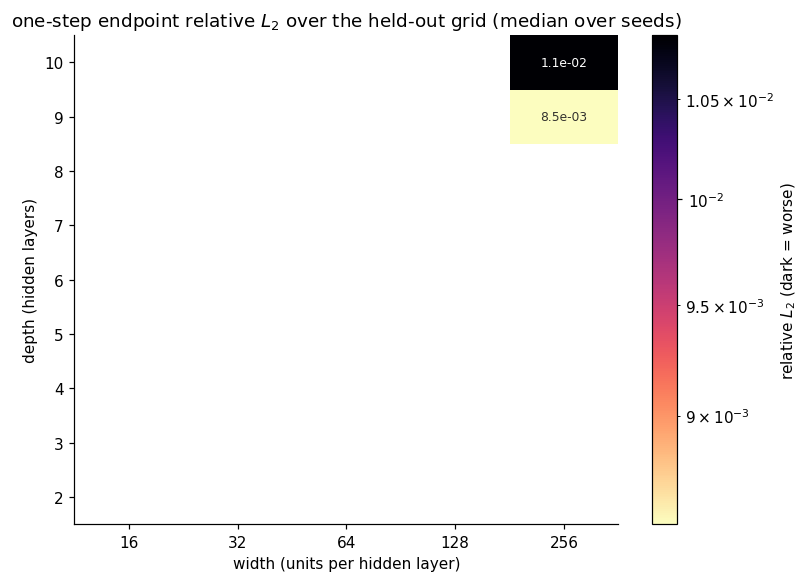

In [3]:
if runs.empty:
    print("no finished runs yet")
else:
    piv = (runs.groupby(["depth", "width"]).rel_l2_end.median()
           .unstack("width").reindex(index=DEPTHS, columns=WIDTHS))
    fig, ax = plt.subplots(figsize=(7.4, 5.4))
    norm = LogNorm(vmin=max(np.nanmin(piv.values), 1e-8),
                   vmax=np.nanmax(piv.values))
    mesh = ax.pcolormesh(np.arange(len(WIDTHS) + 1), np.arange(len(DEPTHS) + 1),
                         piv.values, norm=norm, cmap="magma_r", shading="flat")
    for i, d in enumerate(DEPTHS):
        for j, w in enumerate(WIDTHS):
            v = piv.loc[d, w]
            if np.isfinite(v):
                ax.text(j + .5, i + .5, f"{v:.1e}", ha="center", va="center",
                        fontsize=8,
                        color="white" if norm(v) > 0.6 else INK)
    ax.set_xticks(np.arange(len(WIDTHS)) + .5, WIDTHS)
    ax.set_yticks(np.arange(len(DEPTHS)) + .5, DEPTHS)
    ax.set_xlabel("width (units per hidden layer)")
    ax.set_ylabel("depth (hidden layers)")
    ax.set_title("one-step endpoint relative $L_2$ over the held-out grid "
                 "(median over seeds)")
    ax.grid(False)
    fig.colorbar(mesh, ax=ax, label="relative $L_2$ (dark = worse)")
    fig.tight_layout()
    fig.savefig(FIGURES / "01_one_step_error_map.png"); plt.show()

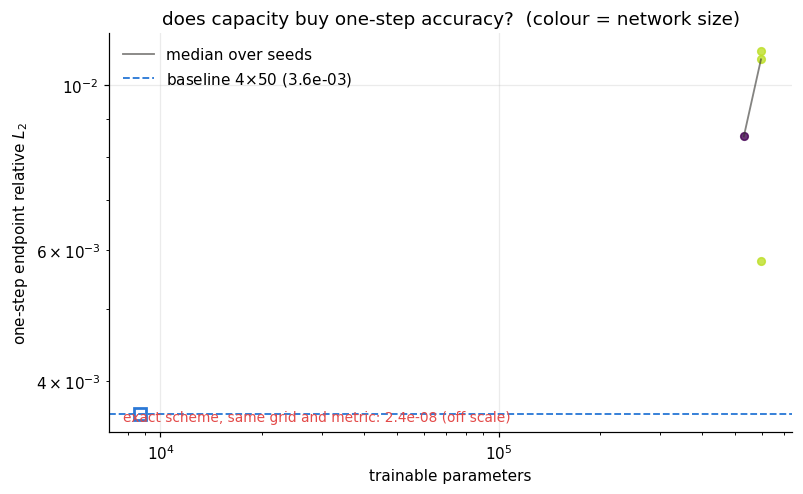

In [4]:
if runs.empty:
    print("no finished runs yet")
else:
    fig, ax = plt.subplots(figsize=(7.4, 4.6))
    p_lo, p_hi = np.log(runs.n_params.min()), np.log(runs.n_params.max())
    span = max(p_hi - p_lo, 1e-9)
    for (d, w), g in runs.groupby(["depth", "width"]):
        col = SIZE_CMAP(0.9 * (np.log(g.n_params.iloc[0]) - p_lo) / span)
        ax.loglog(g.n_params, g.rel_l2_end, "o", color=col, ms=5, alpha=0.8)
    med = runs.groupby("n_params").rel_l2_end.median()
    ax.loglog(med.index, med.values, "-", color=INK, lw=1.2, alpha=0.6,
              label="median over seeds")
    ax.axhline(BASE_MED, color=NET, ls="--", lw=1.2,
               label=f"baseline 4$\\times$50 ({BASE_MED:.1e})")
    ax.plot([BASE_PARAMS], [BASE_MED], "s", color=NET, ms=8, mfc="none", mew=1.8)
    ax.text(0.02, 0.03, "exact scheme, same grid and metric: "
            f"{SCHEME_Q8:.1e} (off scale)", transform=ax.transAxes,
            fontsize=9, color=REF)
    ax.set_xlabel("trainable parameters")
    ax.set_ylabel("one-step endpoint relative $L_2$")
    ax.set_title("does capacity buy one-step accuracy?  (colour = network size)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / "02_one_step_error_vs_params.png"); plt.show()

## 3. Is the optimiser at the same floor as the error?

The reconstruction loss is what L-BFGS actually minimises; the endpoint error is what we
care about. If the final loss keeps falling with size while the endpoint error does not,
the network is spending its extra capacity on something the loss rewards and the error
ignores — a loss-design problem, not a capacity problem. If the two floor together, the
optimiser simply stops making progress at the same place regardless of size — an
optimisation problem. If both fall together, capacity was the bottleneck after all.

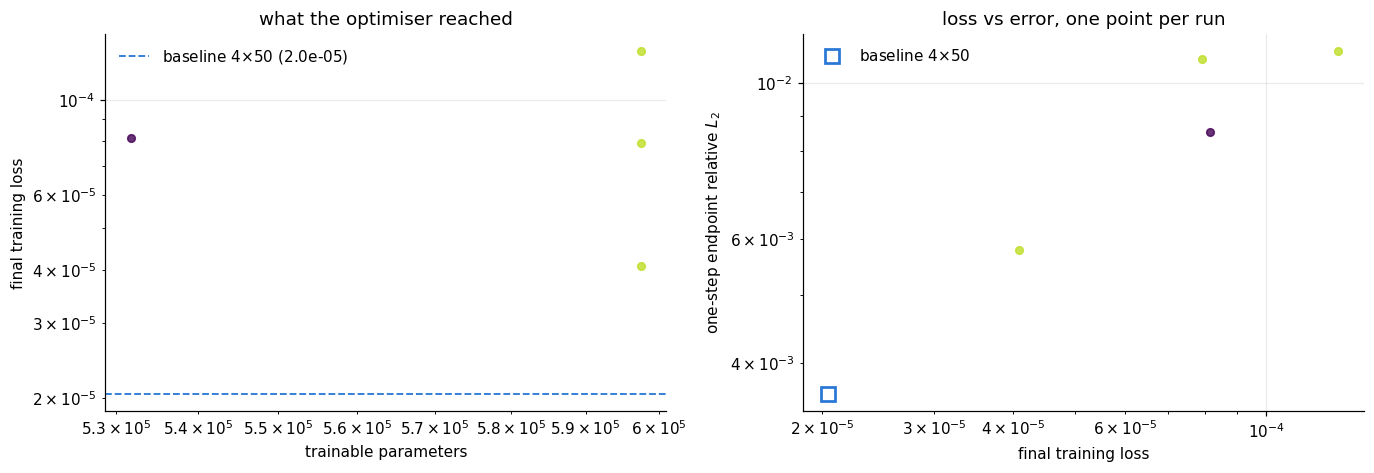

In [5]:
if runs.empty:
    print("no finished runs yet")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
    p_lo, p_hi = np.log(runs.n_params.min()), np.log(runs.n_params.max())
    span = max(p_hi - p_lo, 1e-9)
    for (d, w), g in runs.groupby(["depth", "width"]):
        col = SIZE_CMAP(0.9 * (np.log(g.n_params.iloc[0]) - p_lo) / span)
        axes[0].loglog(g.n_params, g.loss, "o", color=col, ms=5, alpha=0.8)
        axes[1].loglog(g.loss, g.rel_l2_end, "o", color=col, ms=5, alpha=0.8)
    base_loss = float(base.loss.median())
    axes[0].axhline(base_loss, color=NET, ls="--", lw=1.2,
                    label=f"baseline 4$\\times$50 ({base_loss:.1e})")
    axes[0].set_xlabel("trainable parameters")
    axes[0].set_ylabel("final training loss")
    axes[0].set_title("what the optimiser reached")
    axes[0].legend()
    axes[1].plot([base_loss], [BASE_MED], "s", color=NET, ms=9, mfc="none",
                 mew=1.8, label="baseline 4$\\times$50")
    axes[1].set_xlabel("final training loss")
    axes[1].set_ylabel("one-step endpoint relative $L_2$")
    axes[1].set_title("loss vs error, one point per run")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(FIGURES / "03_loss_vs_size_and_error.png"); plt.show()

## 4. Fifty steps: does the high-horizon error move with size?

The study's real target. Every trained network is chained for 50 steps ($t = 40$, six laps)
from the same 108 held-out starting states as the discrete-time study's test set, the
reference walking alongside, and scored at every step by the agreed metric — mean over
components of $\big((y - \hat y)/\lVert y\rVert\big)^2$ with $\lVert y\rVert$ the modulus of
the true state. First the landscape at the far end (six laps), then the full time evolution
for a representative selection, with the baseline overlaid from the discrete-time study's
own saved test-set scores.

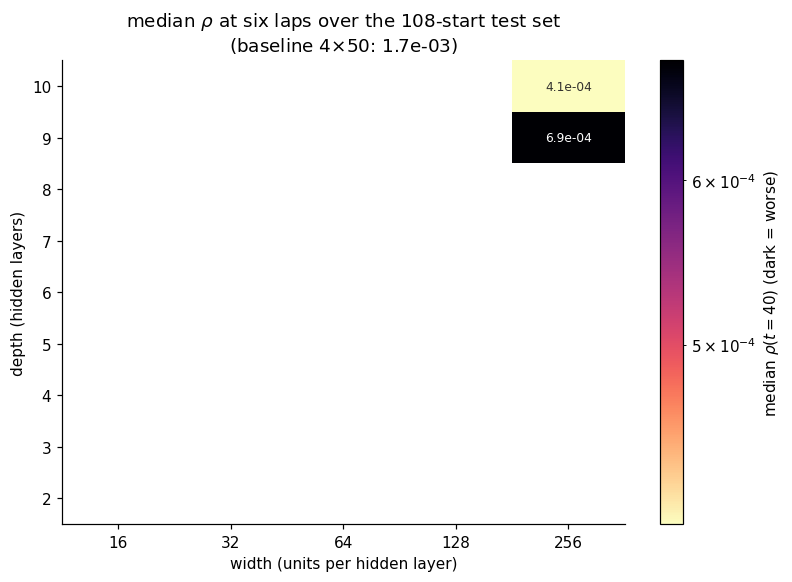

In [6]:
if runs.empty:
    print("no finished runs yet")
else:
    def combo_rho(d, w):
        arrs = [rho_by[t] for t in
                (f"d{d:02d}_w{w:03d}_s{s}" for s in SEEDS) if t in rho_by]
        return np.stack(arrs) if arrs else None      # (seeds, 50, 108)

    end_med = pd.DataFrame(
        [dict(depth=d, width=w, rho=float(np.median(r[:, -1, :])))
         for d in DEPTHS for w in WIDTHS
         if (r := combo_rho(d, w)) is not None])
    piv = (end_med.set_index(["depth", "width"]).rho
           .unstack("width").reindex(index=DEPTHS, columns=WIDTHS))
    base_end = float(np.median(base_rho[:, -1, :]))

    fig, ax = plt.subplots(figsize=(7.4, 5.4))
    norm = LogNorm(vmin=np.nanmin(piv.values), vmax=np.nanmax(piv.values))
    mesh = ax.pcolormesh(np.arange(len(WIDTHS) + 1), np.arange(len(DEPTHS) + 1),
                         piv.values, norm=norm, cmap="magma_r", shading="flat")
    for i, d in enumerate(DEPTHS):
        for j, w in enumerate(WIDTHS):
            v = piv.loc[d, w] if (d, w) in piv.stack().index else np.nan
            if np.isfinite(v):
                ax.text(j + .5, i + .5, f"{v:.1e}", ha="center", va="center",
                        fontsize=8, color="white" if norm(v) > 0.6 else INK)
    ax.set_xticks(np.arange(len(WIDTHS)) + .5, WIDTHS)
    ax.set_yticks(np.arange(len(DEPTHS)) + .5, DEPTHS)
    ax.set_xlabel("width (units per hidden layer)")
    ax.set_ylabel("depth (hidden layers)")
    ax.set_title("median $\\rho$ at six laps over the 108-start test set\n"
                 f"(baseline 4$\\times$50: {base_end:.1e})")
    ax.grid(False)
    fig.colorbar(mesh, ax=ax, label="median $\\rho(t=40)$ (dark = worse)")
    fig.tight_layout()
    fig.savefig(FIGURES / "04_six_lap_error_map.png"); plt.show()

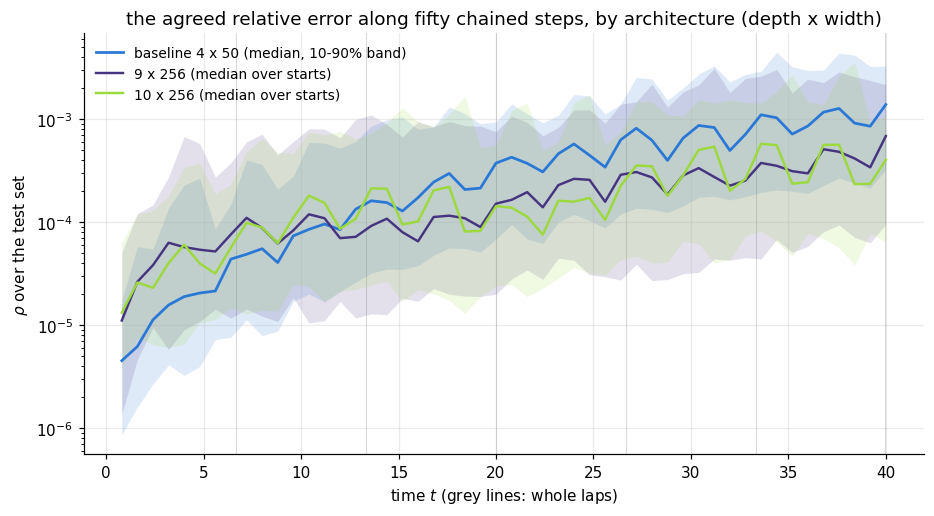

In [7]:
if runs.empty:
    print("no finished runs yet")
else:
    done = set(zip(runs.depth, runs.width))
    smallest = min(done, key=lambda dw: (dw[1], dw[0]))
    largest = max(done, key=lambda dw: (dw[1], dw[0]))
    best = (end_med.loc[end_med.rho.idxmin()] if not end_med.empty else None)
    picks = {f"{d} x {w}": combo_rho(d, w)
             for d, w in dict.fromkeys(
                 [smallest, largest,
                  (int(best.depth), int(best.width)) if best is not None
                  else largest])}

    fig, ax = plt.subplots(figsize=(8.6, 4.8))
    base_med_t = np.median(np.median(base_rho, axis=0), axis=1)
    lo = np.percentile(np.median(base_rho, axis=0), 10, axis=1)
    hi = np.percentile(np.median(base_rho, axis=0), 90, axis=1)
    ax.fill_between(test_t, lo, hi, color=NET, alpha=0.15, lw=0)
    ax.semilogy(test_t, base_med_t, color=NET, lw=1.8,
                label="baseline 4 x 50 (median, 10-90% band)")
    for k, (label, r) in enumerate(picks.items()):
        rm = np.median(r, axis=0)                      # (50, 108) over seeds
        col = SIZE_CMAP(0.15 + 0.7 * k / max(len(picks) - 1, 1))
        ax.semilogy(test_t, np.median(rm, axis=1), color=col, lw=1.6,
                    label=f"{label} (median over starts)")
        ax.fill_between(test_t, np.percentile(rm, 10, axis=1),
                        np.percentile(rm, 90, axis=1), color=col,
                        alpha=0.15, lw=0)
    for k in range(1, 7):
        ax.axvline(k * tr.LAP, color="0.85", lw=0.7, zorder=0)
    ax.set_xlabel("time $t$ (grey lines: whole laps)")
    ax.set_ylabel(r"$\rho$ over the test set")
    ax.set_title("the agreed relative error along fifty chained steps, "
                 "by architecture (depth x width)")
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(FIGURES / "05_test_set_error_vs_time.png"); plt.show()

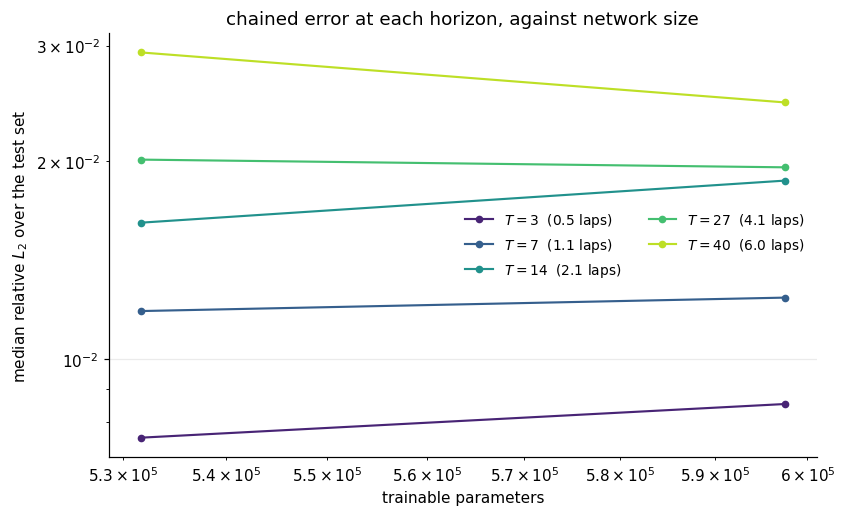

In [8]:
if runs.empty:
    print("no finished runs yet")
else:
    def horizon_med(chains):
        # median over the 108 starts of the relative L2 up to each horizon
        out = {}
        for T in tr.LONG_HORIZONS:
            msk = test_t <= T + 1e-9
            num = np.linalg.norm((chains - test_ref)[msk], axis=(0, 2))
            den = np.linalg.norm(test_ref[msk], axis=(0, 2))
            out[f"T{T:g}"] = float(np.median(num / den))
        return out

    rows_h = []
    for _, r in runs.iterrows():
        rows_h.append(dict(depth=r.depth, width=r.width, seed=r.seed,
                           n_params=r.n_params, **horizon_med(chains_by[r.tag])))
    hor = pd.DataFrame(rows_h)

    fig, ax = plt.subplots(figsize=(7.8, 4.8))
    for k, T in enumerate(tr.LONG_HORIZONS):
        med = hor.groupby("n_params")[f"T{T:g}"].median()
        col = SIZE_CMAP(0.1 + 0.8 * k / (len(tr.LONG_HORIZONS) - 1))
        ax.loglog(med.index, med.values, "o-", color=col, ms=4, lw=1.4,
                  label=f"$T = {T:g}$  ({T / tr.LAP:.1f} laps)")
    ax.set_xlabel("trainable parameters")
    ax.set_ylabel("median relative $L_2$ over the test set")
    ax.set_title("chained error at each horizon, against network size")
    ax.legend(fontsize=9, ncols=2)
    fig.tight_layout()
    fig.savefig(FIGURES / "06_horizon_error_vs_params.png"); plt.show()

## 5. Verdict

Computed from whatever has finished, restated in words. The three-way diagnosis from
section 3 is repeated with numbers: **capacity-limited** (loss and error both fall with
size), **optimisation-limited** (both floor together regardless of size), or
**loss-limited** (loss falls, error doesn't).

In [9]:
if runs.empty:
    print("no finished runs yet")
else:
    total = len(DEPTHS) * len(WIDTHS) * len(SEEDS)
    print(f"coverage: {len(runs)}/{total} runs "
          f"({len(done)}/{len(DEPTHS) * len(WIDTHS)} architectures)")

    b = runs.loc[runs.rel_l2_end.idxmin()]
    print(f"\nbest one-step run: {b.depth:.0f} hidden layers x {b.width:.0f} "
          f"units (seed {b.seed:.0f}) at {b.rel_l2_end:.2e} "
          f"vs baseline median {BASE_MED:.2e} "
          f"({BASE_MED / b.rel_l2_end:.1f}x better) "
          f"vs exact scheme {SCHEME_Q8:.2e} "
          f"({b.rel_l2_end / SCHEME_Q8:.0f}x above it)")

    if not end_med.empty:
        e = end_med.loc[end_med.rho.idxmin()]
        base_end = float(np.median(base_rho[:, -1, :]))
        print(f"best six-lap architecture: {e.depth:.0f} x {e.width:.0f} at "
              f"median rho {e.rho:.2e} vs baseline {base_end:.2e} "
              f"({base_end / e.rho:.1f}x better)")

    big = runs[runs.n_params >= runs.n_params.median()]
    small = runs[runs.n_params < runs.n_params.median()]
    if len(big) and len(small):
        print(f"\nlarger half of the sweep vs smaller half "
              f"(median one-step error): "
              f"{big.rel_l2_end.median():.2e} vs {small.rel_l2_end.median():.2e}")
        print(f"larger half vs smaller half (median final loss): "
              f"{big.loss.median():.2e} vs {small.loss.median():.2e}")

    if len(runs) == total:
        assert runs.rel_l2_end.notna().all() and runs.loss.notna().all()
        assert (runs.groupby(["depth", "width"]).seed.count() == 3).all()
        print("\nsweep complete; all runs loaded and finite")
    else:
        print("\nsweep incomplete -- re-run this notebook as jobs land")

coverage: 4/135 runs (2/45 architectures)

best one-step run: 10 hidden layers x 256 units (seed 1) at 5.80e-03 vs baseline median 3.61e-03 (0.6x better) vs exact scheme 2.38e-08 (243584x above it)
best six-lap architecture: 10 x 256 at median rho 4.09e-04 vs baseline 1.73e-03 (4.2x better)

larger half of the sweep vs smaller half (median one-step error): 1.08e-02 vs 8.54e-03
larger half vs smaller half (median final loss): 7.93e-05 vs 8.16e-05

sweep incomplete -- re-run this notebook as jobs land
